# Personalized Movie Discovery Engine

This notebook demonstrates the evolution of a recommendation system from a standard Collaborative Filtering baseline to a Deep Learning architecture (Neural Collaborative Filtering).

## Phase 1: Business Objectives & KPIs

### Core Business Goal
To increase user engagement, retention, and content consumption by providing a highly personalized movie discovery experience.

### Key Evaluation Metrics
1. **Rating Prediction (Explicit Feedback)**:
   - **RMSE (Root Mean Square Error)**: Penalizes larger prediction errors heavily.
   - **MAE (Mean Absolute Error)**: Provides a linear measure of average error magnitude.
2. **Ranking & Discovery (Implicit Focus)**:
   - **Precision@K**: The proportion of recommended items in the top-K set that are relevant.
   - **Recall@K**: The proportion of relevant items found in the top-K recommendations.

Below, we perform a brief Exploratory Data Analysis (EDA) to understand the distribution of user ratings and the inherent sparsity of the User-Item matrix.

In [3]:
!pip install surprise

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 4.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2554974 sha256=c60f03dd933bc3ff7fa39b9c1f075b02c763b3c7d8663a941a67839dee722264
  Stored in directory: /root/.cache/pip/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise


/tmp/ipykernel_2351/2689394630.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=ratings_df, x='rating', palette='viridis')


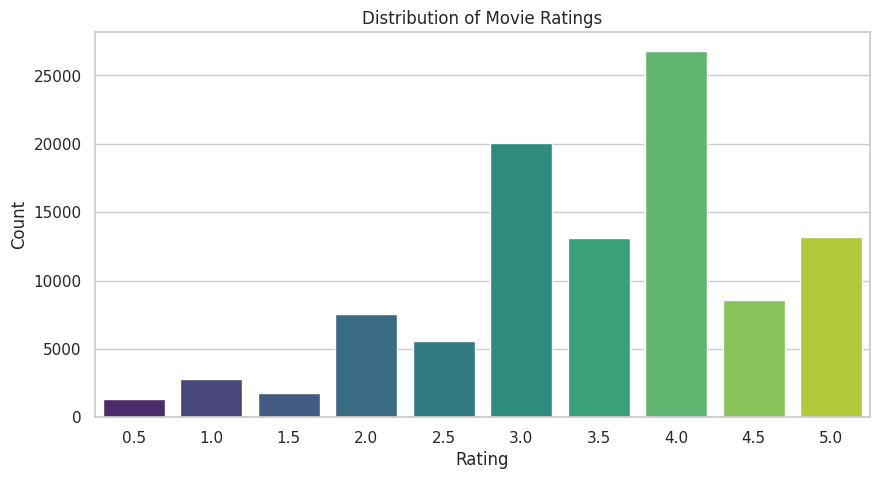

Total Users: 610
Total Movies: 9724
User-Item Matrix Sparsity: 98.3000%


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")

# 1. Load Data
# Expecting dataset to be present in ./dataset/ directory
movies_df = pd.read_csv('movies.csv')
ratings_df = pd.read_csv('ratings.csv')

# 2. EDA: Rating distributions
plt.figure(figsize=(10, 5))
sns.countplot(data=ratings_df, x='rating', palette='viridis')
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

# 3. EDA: Sparsity calculation
num_users = ratings_df['userId'].nunique()
num_movies = ratings_df['movieId'].nunique()
actual_interactions = len(ratings_df)
total_possible_interactions = num_users * num_movies

sparsity = 1.0 - (actual_interactions / total_possible_interactions)
print(f"Total Users: {num_users}")
print(f"Total Movies: {num_movies}")
print(f"User-Item Matrix Sparsity: {sparsity:.4%}")

## Phase 2: Baseline Collaborative Filtering (CF)

### The User-Item Interaction Matrix
Collaborative Filtering relies on the User-Item Interaction Matrix, where rows represent users, columns represent items (movies), and the values are the interactions (ratings). Since users only rate a tiny fraction of all available movies, this matrix is highly sparse.
Our baseline models aim to fill in the missing entries by identifying patterns among similar users (User-Based CF) or similar items (Item-Based CF). Matrix Factorization techniques like SVD decompose this large matrix into lower-dimensional user and item latent factor matrices.

Here, we implement a baseline model using `scikit-surprise`.

In [6]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Create User-Item Matrix
user_item_matrix = ratings_df.pivot(index='userId', columns='movieId', values='rating')

# 2. Compute Item-Based Similarity (Cosine Similarity)
# Fill NaN with 0 for similarity computation
matrix_filled = user_item_matrix.fillna(0)
item_similarity = cosine_similarity(matrix_filled.T)
item_similarity_df = pd.DataFrame(item_similarity, index=user_item_matrix.columns, columns=user_item_matrix.columns)

# 3. Predict Ratings and Evaluate on a sample
sample_ratings = ratings_df.sample(n=2000, random_state=42) # Evaluate on a subset for speed
actuals = []
predictions = []

for _, row in sample_ratings.iterrows():
    user = row['userId']
    item = row['movieId']
    actual = row['rating']

    # Get user's ratings
    user_ratings = user_item_matrix.loc[user].dropna()

    # Get similarities of this item with the items the user has rated
    if item in item_similarity_df.columns:
        similarities = item_similarity_df.loc[item, user_ratings.index]
        if similarities.sum() > 0:
            pred = np.dot(similarities, user_ratings) / similarities.sum()
        else:
            pred = user_ratings.mean() # fallback to user's average rating
    else:
        pred = user_ratings.mean()

    actuals.append(actual)
    predictions.append(pred)

# 4. Calculate RMSE and MAE
rmse = np.sqrt(mean_squared_error(actuals, predictions))
mae = mean_absolute_error(actuals, predictions)

print(f"Baseline CF RMSE (Item-Based): {rmse:.4f}")
print(f"Baseline CF MAE (Item-Based): {mae:.4f}")

Baseline CF RMSE (Item-Based): 0.9207
Baseline CF MAE (Item-Based): 0.7086


## Phase 3: Neural Collaborative Filtering (NCF)

While standard Matrix Factorization models linear interactions (via dot products of latent factors), Neural Collaborative Filtering uses Neural Networks to model complex, non-linear interactions between users and items.

### Mathematical Reference
In NCF, the predicted rating $\hat{y}_{ui}$ is defined as:
$$\hat{y}_{ui} = f(P^T v_u, Q^T v_i | P, Q, \Theta)$$
Where:
- $v_u$ and $v_i$ are the one-hot vectors for user $u$ and item $i$.
- $P$ and $Q$ are the latent factor (embedding) matrices for users and items.
- $\Theta$ represents the model parameters (weights of the Multi-Layer Perceptron).
- $f$ is the interaction function (the neural network).

In [7]:
import torch
import torch.nn as nn

class NCF(nn.Module):
    def __init__(self, num_users, num_items, embedding_dim=32, layers=[64, 32, 16, 8]):
        super(NCF, self).__init__()

        # Embedding Layers (Representing P and Q latent factor matrices)
        self.user_embedding = nn.Embedding(num_features=num_users, embedding_dim=embedding_dim)
        self.item_embedding = nn.Embedding(num_features=num_items, embedding_dim=embedding_dim)

        # Multi-Layer Perceptron (MLP) to learn the non-linear interaction function (f)
        self.mlp_layers = nn.Sequential(
            nn.Linear(embedding_dim * 2, layers[0]),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(layers[0], layers[1]),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(layers[1], layers[2]),
            nn.ReLU(),
            nn.Linear(layers[2], layers[3]),
            nn.ReLU(),
            nn.Linear(layers[3], 1)
        )

    def forward(self, user_indices, item_indices):
        # Retrieve embeddings
        user_emb = self.user_embedding(user_indices)
        item_emb = self.item_embedding(item_indices)

        # Concatenate user and item embeddings
        vector = torch.cat([user_emb, item_emb], dim=-1)

        # Pass through the MLP to predict rating
        prediction = self.mlp_layers(vector)
        return prediction.squeeze()

# Example instantiation
# model = NCF(num_users=num_users, num_items=num_movies)